# 4 Pre-Processing and Training Data<a id='4_Pre-Processing_and_Training_Data'></a>

## 4.1 Contents<a id='4.1_Contents'></a>
* [4 Pre-Processing and Training Data](#4_Pre-Processing_and_Training_Data)
  * [4.1 Contents](#4.1_Contents)
  * [4.2 Introduction](#4.2_Introduction)
  * [4.3 Imports](#4.3_Imports)
  * [4.4 Load Data](#4.4_Load_Data)
  * [4.5 Principal Components Analysis](#4.5_Principal_Components_Analysis)
  * [4.6 Train/Test Split](#4.6_Train/Test_Split)
  * [4.7 Scale Dataset](#4.7_Scale_Dataset)
  * [4.8 Save Train Test Datasets](#4.13_Save_Train_Test_Datasets)
  * [4.9 Summary](#4.14_Summary)

## 4.2. Introduction<a id='4.2_Introduction'></a>

In the preceding notebooks, we performed exploratory data analysis and determined the features and overall dataset to be used for modeling. We found some missing data for co2, gdp, energy_per_capita features that we handled by dropping the countries entirely or backfilling data for 1 to 2 years.

In this notebook we will do PCA analysis and finalize our feature set, create train/test sets and standardize our data. Next we will save the train/test sets for modeling in the next step.

##  4.3 Imports<a id='4.3_Imports'></a>

In [75]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import datetime
from library.sb_utils import save_file

## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [76]:
co2_data = pd.read_csv('../data/processed/model_ready_data.csv')
co2_data.head()

,country,year,iso_code,log_co2,log_gdp_per_capita,log_energy_per_capita,log_population,log_co2_per_capita
0,Afghanistan,1990,AFG,0.705076,6.989063,7.826789,16.304215,-1.783791
1,Afghanistan,1991,AFG,0.649195,6.891983,6.928611,16.320128,-1.857899
2,Afghanistan,1992,AFG,0.393393,6.861405,6.426577,16.401693,-2.189256
3,Afghanistan,1993,AFG,0.396761,6.489406,6.302176,16.519765,-2.302585
4,Afghanistan,1994,AFG,0.374318,6.188986,6.182800,16.603653,-2.419119


In [77]:
#ensure there is no missing data
co2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4853 entries, 0 to 4852
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                4853 non-null   object 
 1   year                   4853 non-null   int64  
 2   iso_code               4853 non-null   object 
 3   log_co2                4853 non-null   float64
 4   log_gdp_per_capita     4853 non-null   float64
 5   log_energy_per_capita  4853 non-null   float64
 6   log_population         4853 non-null   float64
 7   log_co2_per_capita     4853 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 303.4+ KB


## 4.5 Principal Components Analysis<a id='4.5_Principal_Components_Analysis'></a>

In [79]:
#preparing and scaling data for PCA Analysis
features = ['log_gdp_per_capita','log_energy_per_capita','log_population']
X=co2_data[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [80]:
#perform PCA Analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

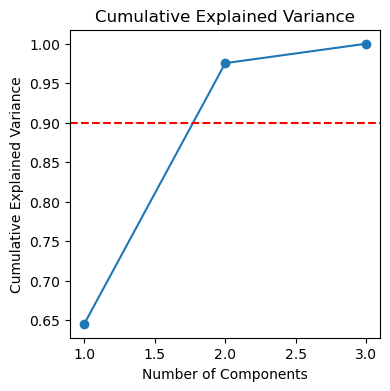

In [81]:
#Cumulative variance plot for PCA Components
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize = (4,4))
plt.plot(range(1, len(features)+1), cum_var, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(0.9, linestyle='--', color='red')
plt.show()

In [82]:
#pca data summary
pca_dataset = pd.DataFrame(pca.components_, columns=features, 
                            index =[f'PC{i+1}' for i in range(len(features))])
pca_dataset

,log_gdp_per_capita,log_energy_per_capita,log_population
PC1,0.702235,0.704213,-0.104641
PC2,0.093083,0.054901,0.994144
PC3,-0.705834,0.707863,0.026997


We can see from the cumulative explained variance plot and PCA components summary above that PC1 component accounts for more than 70% of the expalined variance and it represents the overall economic and energy development per capita. PC2 seems to be entirely driven by population size and PC3 represents the contrast between energy and gdp per capita.

We did PCA Analysis to understand if we could use PCA components instead of our log features for modeling. Our first PCA component seems to capture majority of the variance pointing to the strong combination of economic and energy features. Our goal is to provide meaningful insights into the drivers of CO2 emissions. Hence, we will not be using PCA components for modeling due to loss of interpretability of key drivers. Multicollinearity was found to be within an acceptable range based on VIF analysis done in exploratory data analysis notebook. Hence, we will proceed with our log features for modeling instead of PCA components.

## 4.6 Train/Test Split<a id='4.6_Train/Test_Split'></a>

Our data is partitioned on country/year and hence we will have to do a time based split for the train and test sets

In [83]:
#First Strategy Train/Test Sets
target = 'log_co2'
num_features = ['log_gdp_per_capita','log_energy_per_capita','log_population']
cat_features = ['country']
data = co2_data.dropna(subset = num_features + cat_features + [target, 'year']).copy()
data = data.sort_values(['country','year'])
train = data[data['year']<=2014].copy()
test = data[data['year']>2014].copy()
X_train = train[num_features + cat_features]
y_train = train[target]
X_test = test[num_features + cat_features]
y_test = test[target]

In [84]:
X_train.shape, X_test.shape

((4043, 4), (810, 4))

In [85]:
y_train.shape, y_test.shape

((4043,), (810,))

In [86]:
#Check the `dtypes` attribute of `X_train` and 'X_test to verify all features are numeric
X_train.dtypes
X_test.dtypes

log_gdp_per_capita       float64
log_energy_per_capita    float64
log_population           float64
country                   object
dtype: object

In [87]:
#Second Strategy Train Test Sets
#Create Test Train Set
target2 = 'log_co2_per_capita'
num_features2 = ['log_gdp_per_capita','log_energy_per_capita']
cat_features2 = ['country']
data2 = co2_data.dropna(subset = num_features2 + cat_features2 + [target2, 'year']).copy()
data2 = data2.sort_values(['country','year'])
train2 = data2[data2['year']<=2014].copy()
test2 = data2[data2['year']>2014].copy()
X_train2 = train2[num_features2 + cat_features2]
y_train2 = train2[target2]
X_test2 = test2[num_features2 + cat_features2]
y_test2 = test2[target2]

## 4.7 Scale Dataset<a id='4.7_Scale_Dataset'></a>

In [88]:
scaler = StandardScaler()
#First Strategy
train_scaled = train.copy()
test_scaled = test.copy()
train_scaled[num_features]=scaler.fit_transform(train_scaled[num_features])
test_scaled[num_features]=scaler.transform(test_scaled[num_features])

#Second Strategy
train2_scaled = train2.copy()
test2_scaled = test2.copy()
train2_scaled[num_features2]=scaler.fit_transform(train2_scaled[num_features2])
test2_scaled[num_features2]=scaler.transform(test2_scaled[num_features2])

Here, we clearly see that CO2 per capita is driven by energy consumption per person followed by moderate impact of gdp per capita and country effect is small meaning differences across countries are largely explained by energy consumption and economic structure.

## 4.13 Save best model object from pipeline<a id='4.12_Save_best_model_object_from_pipeline'></a>

In [89]:
#save train/test datasets to csv files for modeling in next step
datapath = '../data/processed'
#First Strategy
save_file(train, 'train.csv', datapath)
save_file(test, 'test.csv', datapath)
save_file(train_scaled, 'train_scaled.csv', datapath)
save_file(test_scaled, 'test_scaled.csv', datapath)
save_file(X_train, 'X_train.csv', datapath)
save_file(X_test, 'X_test.csv', datapath)
save_file(y_train, 'y_train.csv', datapath)
save_file(y_test, 'y_test.csv', datapath)

#Second Strategy
save_file(train2, 'train2.csv', datapath)
save_file(test2, 'test2.csv', datapath)
save_file(train2_scaled, 'train2_scaled.csv', datapath)
save_file(test2_scaled, 'test2_scaled.csv', datapath)
save_file(X_train2, 'X_train2.csv', datapath)
save_file(X_test2, 'X_test2.csv', datapath)
save_file(y_train2, 'y_train2.csv', datapath)
save_file(y_test2, 'y_test2.csv', datapath)

Writing file.  "../data/processed\train.csv"
Writing file.  "../data/processed\test.csv"
Writing file.  "../data/processed\train_scaled.csv"
Writing file.  "../data/processed\test_scaled.csv"
Writing file.  "../data/processed\X_train.csv"
Writing file.  "../data/processed\X_test.csv"
Writing file.  "../data/processed\y_train.csv"
Writing file.  "../data/processed\y_test.csv"
Writing file.  "../data/processed\train2.csv"
Writing file.  "../data/processed\test2.csv"
Writing file.  "../data/processed\train2_scaled.csv"
Writing file.  "../data/processed\test2_scaled.csv"
Writing file.  "../data/processed\X_train2.csv"
Writing file.  "../data/processed\X_test2.csv"
Writing file.  "../data/processed\y_train2.csv"
Writing file.  "../data/processed\y_test2.csv"


## 4.14 Summary<a id='4.13_Summary'></a>

1. We started by loading the model ready dataset with log features created during Exploratory Data Analysis step. 

2. We checked for missing values for all features and target variable and made sure the dataset looked complete.

3. Principal Components Analysis was done to address multicollinearity on our Standardized features (log_energy_per_capita, log_gdp_per_capita and log_population). The first 1 to 2 features captured majority of the variance. However, since the components were a combination of features, it reduced interpretability. We decided to stick with the original features as they were interpretable, did not have severe multicollinearity and we did not need dimensionality reduction for our dataset because we only had 3 features to begin with.

4. Train/Test sets were created for 2 different modeling strategies to capture different perspectives.

* For the first train/test split, log_co2 (total co2 emissions) was our target and primary features were log_population, log_energy_per_capita & log_gdp_per_capita.

* For the second train/test split, log_co2_per_capita was our target and log_energy_per_capita and log_gdp_per_capita were our primary features.

5. Train/Test split was done in a time-aware manner since our dataset is a time series (country/year level data for 19 years).

6. Features were standardized to ensure model readiness.